# ¿El modelo mira el balón o mira el césped?

### Auditoría con SHAP de un clasificador ViT sobre escenas de fútbol

**Diego Linares** · Universidad del Valle de Guatemala · Inteligencia Artificial Responsable

---

## La pregunta

Cuando un clasificador responde `soccer ball` ante una escena de fútbol, **¿qué parte de la
imagen sostiene esa respuesta?**

Importa porque una etiqueta correcta no garantiza un mecanismo correcto. Los balones de fútbol
aparecen casi siempre sobre césped, rodeados de gente con uniforme. Si el modelo aprendió a
responder al *escenario* en vez de al *objeto*, seguirá acertando mientras el escenario se
mantenga y fallará en cuanto cambie.

## El diseño

Se fija la clase (`soccer ball`) y se varía **una sola cosa**: el área que ocupa el balón,
a lo largo de dos órdenes de magnitud.

| | Condición | Área del balón |
|---|---|---|
| **A** | Close-up, contexto casi ausente | ~70 % |
| **B** | Balón sobre el campo | ~20 % |
| **C** | Escena de partido completa | ~1 % |

## Lo que hace este notebook

No se limita a producir mapas de calor: los **somete a pruebas que pueden refutarlos**.

1. **Concentración** — cuánta evidencia cae dentro del balón frente a lo que caería por azar.
2. **Curva de supresión** — borrar píxeles en orden de atribución debe degradar la predicción
   más rápido que borrarlos al azar. Si no, las atribuciones no son fieles.
3. **Ablaciones** — la prueba causal: ¿el balón **basta**? ¿el balón es **necesario**?

Este notebook es la única fuente de verdad del proyecto: genera los JSON de resultados, las
figuras y las tablas LaTeX que consume `paper/paper.tex`. Ninguna cifra del paper se escribe
a mano.

## 0. Entorno

La celda siguiente instala las dependencias solo si faltan, de modo que el notebook corre
igual en local que en Colab.

In [1]:
import importlib.util
import subprocess
import sys

FALTANTES = [
    paquete
    for modulo, paquete in [
        ("torch", "torch"),
        ("transformers", "transformers"),
        ("shap", "shap"),
        ("cv2", "opencv-python"),
        ("matplotlib", "matplotlib"),
    ]
    if importlib.util.find_spec(modulo) is None
]

if FALTANTES:
    print("Instalando:", ", ".join(FALTANTES))
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *FALTANTES], check=True)
else:
    print("Todas las dependencias ya estaban presentes.")

Todas las dependencias ya estaban presentes.


In [2]:
import hashlib
import json
import re
import time
import urllib.parse
import urllib.request
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import shap
import torch
import transformers
from matplotlib.patches import Rectangle
from PIL import Image
from transformers import AutoImageProcessor, AutoModelForImageClassification

VERSIONES = {
    "python": ".".join(map(str, sys.version_info[:3])),
    "torch": torch.__version__,
    "transformers": transformers.__version__,
    "shap": shap.__version__,
    "numpy": np.__version__,
}
for clave, valor in VERSIONES.items():
    print(f"{clave:14s} {valor}")

python         3.14.2
torch          2.10.0+cu128
transformers   5.14.1
shap           0.52.0
numpy          2.4.1


## 1. Parámetros

Todo lo que puede cambiar los resultados vive aquí y se guarda dentro de cada archivo de
salida, para que cualquier cifra pueda rastrearse hasta la corrida que la produjo.

`EVALS` es el presupuesto de evaluaciones del modelo por imagen. Con **2000** se obtienen los
mapas del paper (unos 5 minutos por imagen en CPU); con **120** el notebook completo corre en
menos de dos minutos y sirve para comprobar que todo funciona.

In [3]:
SEED = 20260902
MODEL_ID = "google/vit-base-patch16-224"
INPUT_SIZE = 224
CLASE_OBJETIVO = "soccer ball"

EVALS = 2000          # presupuesto de evaluaciones SHAP por imagen
BATCH = 50            # imagenes enmascaradas por lote
SIGMA_DESENFOQUE = 15 # intensidad del desenfoque que sustituye el contenido borrado
FRACCIONES = [0.0, 0.02, 0.05, 0.10, 0.15, 0.20, 0.30, 0.40, 0.50, 0.70, 1.0]
SEMILLAS_AZAR = [0, 1, 2]

ROOT = Path.cwd()
IMAGES_DIR = ROOT / "data" / "images"
RESULTS_DIR = ROOT / "results"
FIGURES_DIR = ROOT / "figures"
TABLAS_DIR = ROOT / "paper" / "generado"
for carpeta in (IMAGES_DIR, RESULTS_DIR, FIGURES_DIR, TABLAS_DIR):
    carpeta.mkdir(parents=True, exist_ok=True)

np.random.seed(SEED)
torch.manual_seed(SEED)
torch.use_deterministic_algorithms(True, warn_only=True)

ETIQUETAS = {
    "close_up": "A. Close-up",
    "campo": "B. Balon en el campo",
    "partido": "C. Escena de partido",
}
print(f"raiz del proyecto: {ROOT}")

raiz del proyecto: C:\Users\dlinares\Documents\UVG\Ultimo Semestre\Responsible AI\LoopEngineering


## 2. Datos

Las imágenes vienen de Wikimedia Commons bajo licencia libre y están **fijadas por título
exacto**, no por una búsqueda: así la descarga es determinista y cualquiera obtiene los mismos
tres archivos. Se registran autor, licencia y `sha256` de cada una.

In [4]:
API = "https://commons.wikimedia.org/w/api.php"
UA = "LoopEngineering/0.1 (proyecto academico UVG; explicabilidad SHAP)"
THUMB_WIDTH = 1024

IMAGENES = {
    "close_up": "File:Soccer Ball (42232038211).jpg",
    "campo": "File:Adidas soccer ball on a grass pitch (Unsplash).jpg",
    "partido": "File:Players and referees before a football match.jpg",
}


def descargar(url: str) -> bytes:
    peticion = urllib.request.Request(url, headers={"User-Agent": UA})
    with urllib.request.urlopen(peticion, timeout=90) as respuesta:
        return respuesta.read()


def texto_plano(extmetadata: dict, clave: str) -> str:
    """Extrae un campo de extmetadata quitando el HTML que a veces trae Commons."""
    crudo = extmetadata.get(clave, {}).get("value", "")
    return " ".join(re.sub(r"<[^>]+>", "", str(crudo)).split())


parametros = {
    "action": "query",
    "titles": "|".join(IMAGENES.values()),
    "prop": "imageinfo",
    "iiprop": "url|extmetadata|size",
    "iiurlwidth": str(THUMB_WIDTH),
    "format": "json",
    "formatversion": "2",
}
respuesta = json.loads(descargar(API + "?" + urllib.parse.urlencode(parametros)))
info = {pagina["title"]: pagina["imageinfo"][0] for pagina in respuesta["query"]["pages"]}

manifiesto = []
for id_local, titulo in IMAGENES.items():
    item = info[titulo]
    meta = item.get("extmetadata", {})
    contenido = descargar(item["thumburl"])
    (IMAGES_DIR / f"{id_local}.jpg").write_bytes(contenido)
    manifiesto.append({
        "id": id_local,
        "archivo": f"{id_local}.jpg",
        "titulo_commons": titulo,
        "pagina": item["descriptionurl"],
        "autor": texto_plano(meta, "Artist"),
        "licencia": texto_plano(meta, "LicenseShortName"),
        "sha256": hashlib.sha256(contenido).hexdigest(),
    })
    print(f"{id_local:9s} {len(contenido):>8,d} B  {manifiesto[-1]['licencia']:10s} {titulo}")

(IMAGES_DIR / "manifest.json").write_text(
    json.dumps({"fuente": "Wikimedia Commons", "imagenes": manifiesto}, indent=2, ensure_ascii=False),
    encoding="utf-8",
)

close_up   482,677 B  CC BY 2.0  File:Soccer Ball (42232038211).jpg


campo      153,675 B  CC0        File:Adidas soccer ball on a grass pitch (Unsplash).jpg


partido    403,152 B  CC0        File:Players and referees before a football match.jpg


1214

### Preprocesamiento

Se escala el lado corto a 224 px y se recorta el centro, sin deformar la escena. Conviene
**mirar** el resultado: si el recorte se comiera el balón en alguna imagen, todo el análisis
posterior estaría midiendo otra cosa.

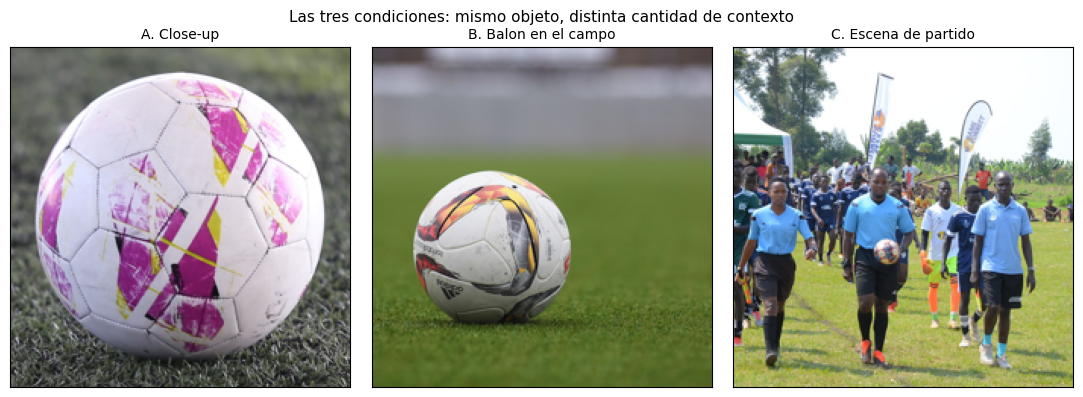

lote de entrada: (3, 224, 224, 3) uint8


In [5]:
def recortar_centro(imagen: Image.Image, lado: int = INPUT_SIZE) -> Image.Image:
    """Escala el lado corto a `lado` y recorta el centro, sin deformar la escena."""
    ancho, alto = imagen.size
    escala = lado / min(ancho, alto)
    imagen = imagen.resize((round(ancho * escala), round(alto * escala)), Image.BICUBIC)
    ancho, alto = imagen.size
    izquierda, arriba = (ancho - lado) // 2, (alto - lado) // 2
    return imagen.crop((izquierda, arriba, izquierda + lado, arriba + lado))


IDS = list(IMAGENES)
X = np.stack([
    np.array(recortar_centro(Image.open(IMAGES_DIR / f"{i}.jpg").convert("RGB"))) for i in IDS
])

figura, ejes = plt.subplots(1, 3, figsize=(11, 4))
for eje, nombre, imagen in zip(ejes, IDS, X):
    eje.imshow(imagen)
    eje.set_title(ETIQUETAS[nombre], fontsize=10)
    eje.set_xticks([]); eje.set_yticks([])
figura.suptitle("Las tres condiciones: mismo objeto, distinta cantidad de contexto", fontsize=11)
figura.tight_layout()
plt.show()
print("lote de entrada:", X.shape, X.dtype)

## 3. Modelo

`google/vit-base-patch16-224`: un Vision Transformer ViT-B/16 con clasificador de 1000 clases
sobre ImageNet-1k. Se usa **tal cual, sin ajuste fino**, y se trata como caja negra: solo se
observan entradas y salidas, que es la condición real de quien audita un modelo de terceros.

In [6]:
procesador = AutoImageProcessor.from_pretrained(MODEL_ID)
modelo = AutoModelForImageClassification.from_pretrained(MODEL_ID)
modelo.eval()
id2label = modelo.config.id2label


def predecir(lote: np.ndarray) -> np.ndarray:
    """f(lote uint8 NxHxWx3) -> logits NxC. Es la unica via de acceso al modelo."""
    imagenes = [Image.fromarray(a.astype(np.uint8)) for a in lote]
    entradas = procesador(images=imagenes, return_tensors="pt")
    with torch.no_grad():
        return modelo(**entradas).logits.numpy()


def probabilidad(lote, indice: int) -> np.ndarray:
    return torch.softmax(torch.from_numpy(predecir(np.stack(lote))), dim=-1).numpy()[:, indice]


POR_NOMBRE = {nombre: idx for idx, nombre in id2label.items()}
OBJETIVO = POR_NOMBRE[CLASE_OBJETIVO]
print(f"clase objetivo: '{CLASE_OBJETIVO}' -> indice {OBJETIVO} de {len(id2label)}")

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

clase objetivo: 'soccer ball' -> indice 805 de 1000


### Predicciones

Las tres imágenes reciben la misma etiqueta. Lo que cambia es la **confianza**.

In [7]:
CLASES_DE_INTERES = [
    "soccer ball", "ballplayer, baseball player", "rugby ball",
    "basketball", "volleyball", "scoreboard",
]

probs = torch.softmax(torch.from_numpy(predecir(X)), dim=-1).numpy()
predicciones = []
for nombre, p in zip(IDS, probs):
    orden = np.argsort(p)[::-1][:5]
    predicciones.append({
        "id": nombre,
        "clase_predicha": id2label[int(orden[0])],
        "confianza": float(p[orden[0]]),
        "top_k": [{"clase": id2label[int(i)], "prob": float(p[i])} for i in orden],
        "clases_de_interes": {c: float(p[POR_NOMBRE[c]]) for c in CLASES_DE_INTERES},
    })
    print(f"\n[{ETIQUETAS[nombre]}] -> {predicciones[-1]['clase_predicha']} "
          f"({predicciones[-1]['confianza']:.3f})")
    for entrada in predicciones[-1]["top_k"]:
        print(f"    {entrada['prob']:.4f}  {entrada['clase']}")

(RESULTS_DIR / "predictions.json").write_text(
    json.dumps({"versiones": VERSIONES, "predicciones": predicciones}, indent=2, ensure_ascii=False),
    encoding="utf-8",
)


[A. Close-up] -> soccer ball (0.997)
    0.9968  soccer ball
    0.0008  golf ball
    0.0004  rugby ball
    0.0003  tennis ball
    0.0002  croquet ball

[B. Balon en el campo] -> soccer ball (0.983)
    0.9829  soccer ball
    0.0071  rugby ball
    0.0046  golf ball
    0.0010  baseball
    0.0007  volleyball

[C. Escena de partido] -> soccer ball (0.104)
    0.1040  soccer ball
    0.0836  rugby ball
    0.0592  volleyball
    0.0461  racket, racquet
    0.0282  stretcher


2948

La confianza cae de **0.997** a **0.104** conforme crece el contexto. En la escena de partido
el modelo queda prácticamente indeciso entre `soccer ball`, `rugby ball` y `volleyball` — pero
sigue acertando, y un sistema que solo registrara la etiqueta lo contaría como acierto.

## 4. Atribuciones SHAP

Se usa el **Partition explainer** con máscara de imagen por *inpainting*. Es agnóstico al
modelo: solo necesita la función de predicción, sin gradientes ni atención.

Dos decisiones que afectan los números:

- **Se atribuye sobre los logits, no sobre la softmax.** Con `p = 0.997` la probabilidad está
  saturada: casi cualquier perturbación produce un cambio numéricamente nulo y el mapa se
  aplana sin que eso signifique ausencia de evidencia.
- **La línea base es la imagen con *inpainting*.** Las atribuciones siempre responden a
  "respecto de qué"; otra línea base daría otros números.

In [8]:
mascara = shap.maskers.Image("inpaint_telea", X[0].shape)
explicador = shap.Explainer(
    predecir, mascara, output_names=[id2label[i] for i in range(len(id2label))]
)

mapas, tiempos = [], []
for i, nombre in enumerate(IDS):
    # Tiempo de CPU y no de reloj: si la maquina se suspende a media corrida, el reloj de
    # pared cuenta la suspension. Ojo: process_time suma todos los hilos de torch.
    inicio = time.process_time()
    valores = explicador(
        X[i:i + 1].astype(np.float32), max_evals=EVALS, batch_size=BATCH, outputs=[OBJETIVO]
    )
    tiempos.append(time.process_time() - inicio)
    mapas.append(valores.values[0, ..., 0].sum(axis=-1))  # colapsa los canales RGB
    print(f"[{nombre}] {tiempos[-1]:.1f}s CPU   suma={mapas[-1].sum():+.4f}")

mapas = np.stack(mapas)
np.savez_compressed(
    RESULTS_DIR / "shap_values.npz",
    ids=np.array(IDS), imagenes=X, mapas=mapas,
    prob_objetivo=probs[:, OBJETIVO], indice_objetivo=OBJETIVO, evals=EVALS,
)

  0%|          | 0/1998 [00:00<?, ?it/s]

PartitionExplainer explainer: 100%|██████████| 1/1 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [04:47, 287.53s/it]              

[close_up] 3305.7s CPU   suma=+13.6401


  0%|          | 0/1998 [00:00<?, ?it/s]

...

[campo] 2954.5s CPU   suma=+13.5072


  0%|          | 0/1998 [00:00<?, ?it/s]

PartitionExplainer explainer: 100%|██████████| 1/1 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [03:17, 197.53s/it]              

[partido] 2308.3s CPU   suma=+5.5259


La suma de atribuciones es independiente del presupuesto de evaluaciones: es la propiedad
aditiva de Shapley, y sirve como verificación de que el cálculo está bien planteado.

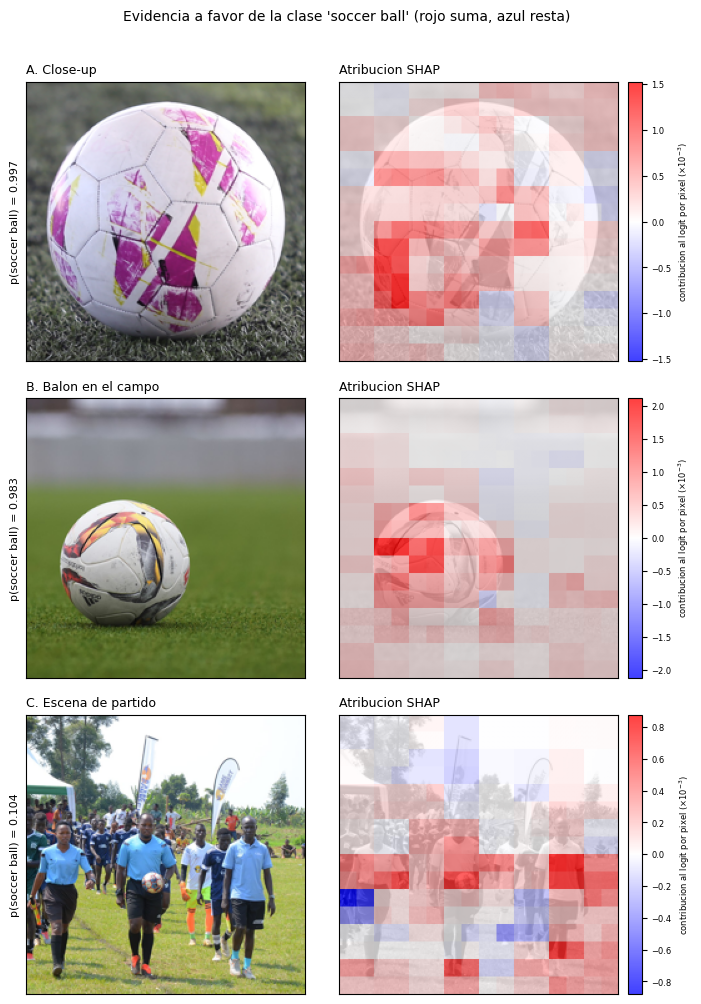

In [9]:
def figura_atribuciones(destino):
    fig, ejes = plt.subplots(len(IDS), 2, figsize=(7.2, 3.4 * len(IDS)))
    for fila, nombre in enumerate(IDS):
        # En milesimas de logit: los valores por pixel son diminutos y la notacion
        # cientifica resulta ilegible en la figura impresa.
        mapa = mapas[fila] * 1e3
        limite = np.percentile(np.abs(mapa), 99.5) or np.abs(mapa).max()

        eje = ejes[fila, 0]
        eje.imshow(X[fila])
        eje.set_title(ETIQUETAS[nombre], fontsize=9, loc="left")
        eje.set_ylabel(f"p({CLASE_OBJETIVO}) = {probs[fila, OBJETIVO]:.3f}", fontsize=8)
        eje.set_xticks([]); eje.set_yticks([])

        eje = ejes[fila, 1]
        eje.imshow(X[fila].astype(np.float32).mean(axis=-1) / 255.0, cmap="gray", vmin=0, vmax=1)
        imagen = eje.imshow(mapa, cmap="bwr", vmin=-limite, vmax=limite, alpha=0.75)
        eje.set_title("Atribucion SHAP", fontsize=9, loc="left")
        eje.set_xticks([]); eje.set_yticks([])
        barra = fig.colorbar(imagen, ax=eje, fraction=0.046, pad=0.03)
        barra.ax.tick_params(labelsize=6)
        barra.set_label(r"contribucion al logit por pixel ($\times 10^{-3}$)", fontsize=6)

    fig.suptitle(
        f"Evidencia a favor de la clase '{CLASE_OBJETIVO}' (rojo suma, azul resta)", fontsize=10
    )
    fig.tight_layout(rect=(0, 0, 1, 0.97))
    fig.savefig(destino, dpi=200, bbox_inches="tight")
    return fig


figura_atribuciones(FIGURES_DIR / "shap_atribuciones.png")
plt.show()

En A y B la evidencia se concentra sobre el balón, aunque el césped también aporta. En C el
panorama cambia: las regiones de mayor atribución se reparten entre los jugadores y el campo,
y el balón no domina el mapa.

**Hasta aquí solo hemos mirado.** Un mapa de calor es una imagen persuasiva, y las imágenes
persuasivas invitan a creerles. El resto del notebook se dedica a comprobar si merece esa fe.

## 5. Verificación

### 5.1 ¿Dónde está el balón?

Cajas envolventes anotadas a mano sobre el recorte de 224×224 y ajustadas con un umbral de
color. Son cajas, **no segmentaciones**: incluyen algo de fondo en las esquinas, lo que hace
*conservadora* la medida de evidencia sobre el objeto.

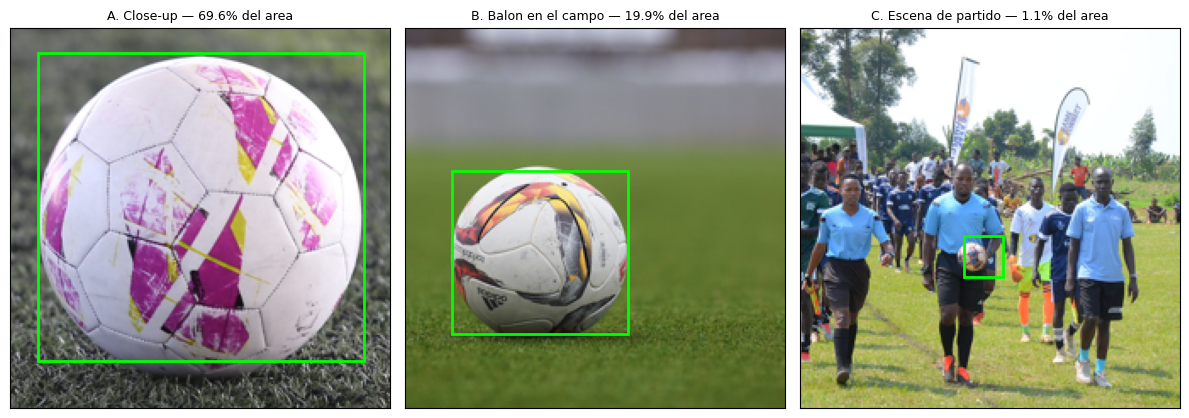

In [10]:
CAJAS = {                       # [x_min, y_min, x_max, y_max]
    "close_up": [16, 14, 208, 196],
    "campo": [27, 84, 131, 180],
    "partido": [96, 122, 119, 146],
}

(ROOT / "data" / "annotations.json").write_text(
    json.dumps({
        "descripcion": "Caja envolvente del balon sobre el recorte central de 224x224 px.",
        "metodo": "Trazada a mano sobre una rejilla y ajustada con un umbral de color.",
        "cajas": CAJAS,
    }, indent=2, ensure_ascii=False),
    encoding="utf-8",
)

figura, ejes = plt.subplots(1, 3, figsize=(12, 4.3))
for eje, nombre in zip(ejes, IDS):
    x0, y0, x1, y1 = CAJAS[nombre]
    eje.imshow(X[IDS.index(nombre)])
    eje.add_patch(Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, ec="lime", lw=2))
    eje.set_title(f"{ETIQUETAS[nombre]} — {(x1-x0)*(y1-y0)/INPUT_SIZE**2:.1%} del area", fontsize=9)
    eje.set_xticks([]); eje.set_yticks([])
figura.tight_layout()
plt.show()

### 5.2 Concentración

¿Qué fracción de la evidencia positiva cae dentro del balón, comparada con la que caería ahí
por puro azar? El cociente es el **enriquecimiento**: 1 significa evidencia repartida como al
azar; valores altos, concentrada en el objeto.

In [11]:
def mascara_caja(nombre: str) -> np.ndarray:
    x0, y0, x1, y1 = CAJAS[nombre]
    dentro = np.zeros((INPUT_SIZE, INPUT_SIZE), dtype=bool)
    dentro[y0:y1, x0:x1] = True
    return dentro


concentracion = {}
for fila, nombre in enumerate(IDS):
    dentro = mascara_caja(nombre)
    positivo = np.clip(mapas[fila], 0, None)
    frac_masa = float(positivo[dentro].sum() / positivo.sum())
    frac_area = float(dentro.mean())
    concentracion[nombre] = {
        "area_objeto": frac_area,
        "masa_positiva_en_objeto": frac_masa,
        "enriquecimiento": frac_masa / frac_area,
    }
    print(f"[{ETIQUETAS[nombre]:22s}] area={frac_area:5.1%}  masa={frac_masa:5.1%}  "
          f"enriquecimiento=x{frac_masa / frac_area:.1f}")

[A. Close-up           ] area=69.6%  masa=83.4%  enriquecimiento=x1.2
[B. Balon en el campo  ] area=19.9%  masa=53.1%  enriquecimiento=x2.7
[C. Escena de partido  ] area= 1.1%  masa= 3.5%  enriquecimiento=x3.2


El enriquecimiento va de ×1.2 a ×3.2: la evidencia está **modestamente** concentrada. En B casi
la mitad cae fuera del balón, lo que invita a concluir que el contexto pesa casi tanto como el
objeto. Guardá esa conclusión: la sección 5.4 la va a desmentir.

### 5.3 Curva de supresión

La prueba de fidelidad. Se borran progresivamente los píxeles en orden de atribución
decreciente y se mide `p(soccer ball)`. Si las atribuciones son fieles, la caída debe ser más
rápida que borrando al azar. El contenido borrado se sustituye por una versión muy desenfocada
de la propia imagen, que destruye la forma local sin introducir bordes artificiales.

In [12]:
def desenfocar(imagen: np.ndarray) -> np.ndarray:
    return cv2.GaussianBlur(imagen.astype(np.uint8), (0, 0), SIGMA_DESENFOQUE).astype(np.float32)


def componer(imagen, fondo, mascara_bool):
    salida = imagen.copy()
    salida[mascara_bool] = fondo[mascara_bool]
    return salida


def curva_supresion(imagen, fondo, mapa, orden=None):
    if orden is None:
        orden = np.argsort(mapa, axis=None)[::-1]   # de mayor a menor atribucion
    lote = []
    for fraccion in FRACCIONES:
        plana = np.zeros(mapa.size, dtype=bool)
        plana[orden[: int(round(fraccion * mapa.size))]] = True
        lote.append(componer(imagen, fondo, plana.reshape(mapa.shape)[..., None].repeat(3, -1)))
    return probabilidad(lote, OBJETIVO)


curvas = {}
for fila, nombre in enumerate(IDS):
    imagen, fondo = X[fila].astype(np.float32), desenfocar(X[fila])
    guiada = curva_supresion(imagen, fondo, mapas[fila])
    azar = np.mean([
        curva_supresion(imagen, fondo, mapas[fila],
                        orden=np.random.default_rng(s).permutation(mapas[fila].size))
        for s in SEMILLAS_AZAR
    ], axis=0)
    curvas[nombre] = {"guiada": guiada.tolist(), "azar": azar.tolist()}
    print(f"[{ETIQUETAS[nombre]:22s}] AUC guiada={np.trapezoid(guiada, FRACCIONES):.3f}  "
          f"vs azar={np.trapezoid(azar, FRACCIONES):.3f}")

[A. Close-up           ] AUC guiada=0.291  vs azar=0.704


[B. Balon en el campo  ] AUC guiada=0.108  vs azar=0.294


[C. Escena de partido  ] AUC guiada=0.021  vs azar=0.042


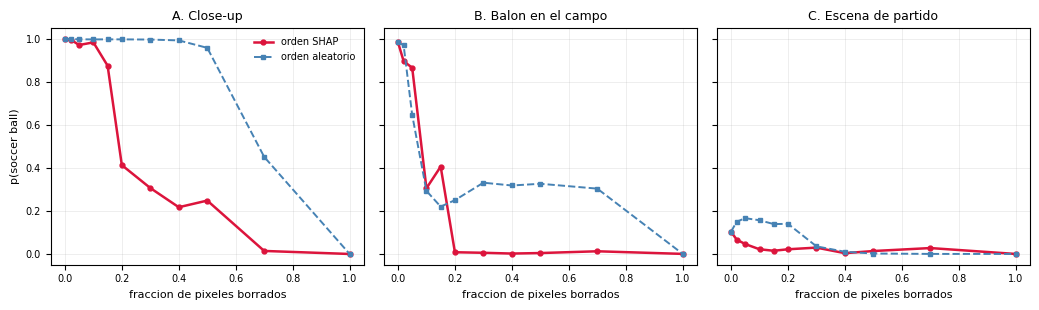

In [13]:
figura, ejes = plt.subplots(1, 3, figsize=(10.5, 3.2), sharey=True)
for eje, nombre in zip(ejes, IDS):
    eje.plot(FRACCIONES, curvas[nombre]["guiada"], "o-", color="crimson", lw=1.8, ms=3.5,
             label="orden SHAP")
    eje.plot(FRACCIONES, curvas[nombre]["azar"], "s--", color="steelblue", lw=1.4, ms=3,
             label="orden aleatorio")
    eje.set_title(ETIQUETAS[nombre], fontsize=9)
    eje.set_xlabel("fraccion de pixeles borrados", fontsize=8)
    eje.tick_params(labelsize=7)
    eje.grid(alpha=0.3, lw=0.5)
ejes[0].set_ylabel("p(soccer ball)", fontsize=8)
ejes[0].legend(fontsize=7, frameon=False)
figura.tight_layout()
figura.savefig(FIGURES_DIR / "curvas_supresion.png", dpi=200, bbox_inches="tight")
plt.show()

**SHAP pasa la prueba en los tres casos**: el orden guiado hunde la predicción mucho más rápido
que el aleatorio. Las atribuciones señalan píxeles que de verdad sostienen la respuesta.

Nótese el panel C: borrar píxeles **al azar** *aumenta* la confianza por encima del valor
original. No es lo que cabe esperar de una predicción bien fundamentada.

### 5.4 Ablaciones — la prueba causal

Las dos preguntas que la concentración no puede responder:

- **¿El balón basta?** Conservar solo la caja y desenfocar todo lo demás.
- **¿El balón es necesario?** Desenfocar solo la caja y conservar el resto.

In [14]:
ablaciones = {}
for fila, nombre in enumerate(IDS):
    imagen, fondo = X[fila].astype(np.float32), desenfocar(X[fila])
    caja3 = mascara_caja(nombre)[..., None].repeat(3, -1)
    solo_objeto, sin_objeto = probabilidad(
        [componer(imagen, fondo, ~caja3), componer(imagen, fondo, caja3)], OBJETIVO
    )
    ablaciones[nombre] = {"solo_objeto": float(solo_objeto), "sin_objeto": float(sin_objeto)}
    original = probs[fila, OBJETIVO]
    print(f"[{ETIQUETAS[nombre]:22s}] original={original:.3f}  "
          f"solo balon={solo_objeto:.3f}  sin balon={sin_objeto:.3f}")

[A. Close-up           ] original=0.997  solo balon=0.994  sin balon=0.020


[B. Balon en el campo  ] original=0.983  solo balon=0.865  sin balon=0.001


[C. Escena de partido  ] original=0.104  solo balon=0.009  sin balon=0.058


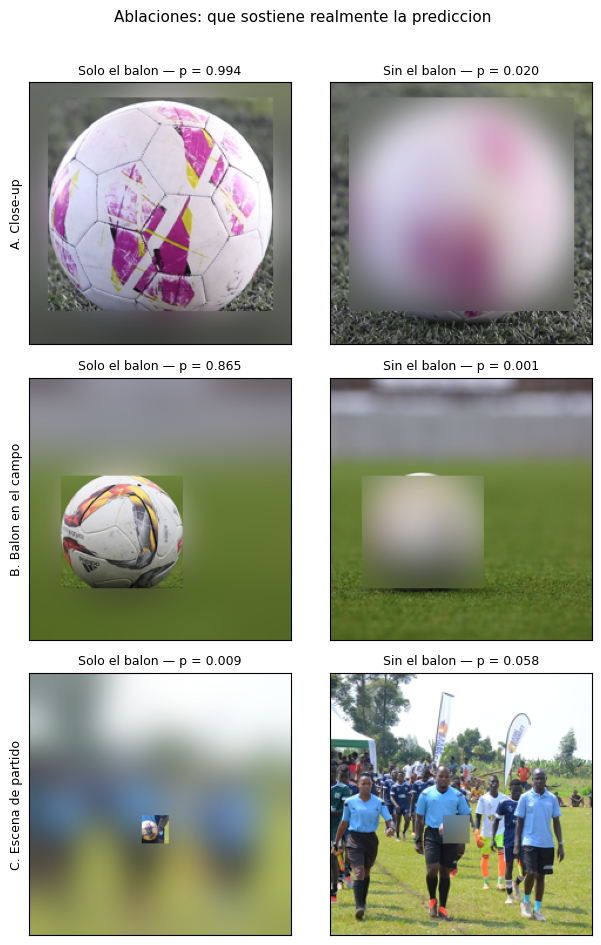

In [15]:
figura, ejes = plt.subplots(len(IDS), 2, figsize=(6.4, 3.2 * len(IDS)))
for fila, nombre in enumerate(IDS):
    imagen, fondo = X[fila].astype(np.float32), desenfocar(X[fila])
    caja3 = mascara_caja(nombre)[..., None].repeat(3, -1)
    for columna, (titulo, compuesta, clave) in enumerate([
        ("Solo el balon", componer(imagen, fondo, ~caja3), "solo_objeto"),
        ("Sin el balon", componer(imagen, fondo, caja3), "sin_objeto"),
    ]):
        eje = ejes[fila, columna]
        eje.imshow(compuesta.astype(np.uint8))
        eje.set_title(f"{titulo} — p = {ablaciones[nombre][clave]:.3f}", fontsize=9)
        eje.set_xticks([]); eje.set_yticks([])
    ejes[fila, 0].set_ylabel(ETIQUETAS[nombre], fontsize=9)
figura.suptitle("Ablaciones: que sostiene realmente la prediccion", fontsize=11)
figura.tight_layout(rect=(0, 0, 1, 0.97))
figura.savefig(FIGURES_DIR / "ablaciones.png", dpi=200, bbox_inches="tight")
plt.show()

Aquí está el resultado del trabajo.

**En A y B el objeto manda.** Conservar solo el balón deja la predicción casi intacta
(0.994 y 0.865); borrarlo la aniquila (0.020 y 0.001). El balón basta y es necesario — aunque
SHAP hubiera repartido casi la mitad de la evidencia fuera de él. **La masa de atribución
sobreestimó el papel del contexto.**

**En C el patrón se invierte.** Solo el balón deja 0.009: *no basta*. Sin el balón queda 0.058
frente a 0.104: *tampoco es necesario*. La predicción correcta se sostiene sobre el escenario.
El modelo está reconociendo **una escena de fútbol, no un balón de fútbol**: acierta por las
razones equivocadas, y ninguna métrica agregada lo detectaría.

## 6. Salidas para el paper

Las tablas de `paper/paper.tex` se generan aquí. Ninguna cifra del documento se transcribe a
mano, así que el texto no puede desincronizarse del experimento.

In [16]:
metricas = []
for fila, nombre in enumerate(IDS):
    c, a = concentracion[nombre], ablaciones[nombre]
    metricas.append({
        "id": nombre,
        "prob_original": float(probs[fila, OBJETIVO]),
        "area_objeto": round(c["area_objeto"], 4),
        "masa_positiva_en_objeto": round(c["masa_positiva_en_objeto"], 4),
        "enriquecimiento": round(c["enriquecimiento"], 2),
        "auc_supresion_guiada": round(float(np.trapezoid(curvas[nombre]["guiada"], FRACCIONES)), 4),
        "auc_supresion_azar": round(float(np.trapezoid(curvas[nombre]["azar"], FRACCIONES)), 4),
        "prob_solo_objeto": a["solo_objeto"],
        "prob_sin_objeto": a["sin_objeto"],
        "segundos_cpu": round(tiempos[fila], 1),
    })

(RESULTS_DIR / "evaluation.json").write_text(
    json.dumps({
        "clase_objetivo": CLASE_OBJETIVO, "evaluaciones_por_imagen": EVALS,
        "fracciones": FRACCIONES, "sigma_desenfoque": SIGMA_DESENFOQUE,
        "semillas_azar": SEMILLAS_AZAR, "versiones": VERSIONES,
        "metricas": metricas, "curvas": curvas,
    }, indent=2, ensure_ascii=False),
    encoding="utf-8",
)
print(f"-> {RESULTS_DIR / 'evaluation.json'}")

-> C:\Users\dlinares\Documents\UVG\Ultimo Semestre\Responsible AI\LoopEngineering\results\evaluation.json


In [17]:
# Las plantillas usan cadenas crudas (rf): en una cadena normal de Python la "b" de \begin
# y la "t" de \toprule se interpretan como caracteres de control y corrompen el LaTeX
# sin lanzar ningun error.
AVISO = "% Generado por analisis_shap.ipynb. No editar a mano."
FIN = r" \\"

filas = "\n".join(
    rf"{ETIQUETAS[p['id']]} & \texttt{{{p['clase_predicha']}}} & {p['confianza']:.3f} & "
    rf"\texttt{{{p['top_k'][1]['clase']}}} & {p['top_k'][1]['prob']:.3f}" + FIN
    for p in predicciones
)
(TABLAS_DIR / "tabla_predicciones.tex").write_text(
    rf"""{AVISO}
\begin{{tabular}}{{llrlr}}
\toprule
Imagen & Clase predicha & $p$ & Segunda clase & $p$""" + FIN + rf"""
\midrule
{filas}
\bottomrule
\end{{tabular}}
""", encoding="utf-8")

filas = "\n".join(
    rf"{ETIQUETAS[m['id']]} & {m['area_objeto']*100:.1f} & "
    rf"{m['masa_positiva_en_objeto']*100:.1f} & {m['enriquecimiento']:.1f} & "
    rf"{m['auc_supresion_guiada']:.3f} & {m['auc_supresion_azar']:.3f} & "
    rf"{m['prob_solo_objeto']:.3f} & {m['prob_sin_objeto']:.3f}" + FIN
    for m in metricas
)
(TABLAS_DIR / "tabla_metricas.tex").write_text(
    rf"""{AVISO}
\begin{{tabular}}{{lrrrrrrr}}
\toprule
& \multicolumn{{3}}{{c}}{{Concentracion}} & \multicolumn{{2}}{{c}}{{AUC supresion}}"""
    rf""" & \multicolumn{{2}}{{c}}{{Ablacion}}""" + FIN + rf"""
\cmidrule(lr){{2-4}} \cmidrule(lr){{5-6}} \cmidrule(lr){{7-8}}
Imagen & Area & Masa & Enriq. & SHAP & Azar & Solo balon & Sin balon""" + FIN + rf"""
& (\%) & (\%) & ($\times$) & & & $p$ & $p$""" + FIN + rf"""
\midrule
{filas}
\bottomrule
\end{{tabular}}
""", encoding="utf-8")

for archivo in sorted(TABLAS_DIR.glob("*.tex")):
    print(f"-> {archivo}")

-> C:\Users\dlinares\Documents\UVG\Ultimo Semestre\Responsible AI\LoopEngineering\paper\generado\tabla_metricas.tex
-> C:\Users\dlinares\Documents\UVG\Ultimo Semestre\Responsible AI\LoopEngineering\paper\generado\tabla_predicciones.tex


## 7. Resumen

Para compilar el paper con estos resultados:

```bash
cd paper
pdflatex paper.tex && bibtex paper && pdflatex paper.tex && pdflatex paper.tex
```

In [18]:
print(f"{'Imagen':24s} {'area':>6s} {'masa':>6s} {'enriq':>6s} {'AUC':>6s} {'azar':>6s} "
      f"{'solo':>6s} {'sin':>6s}")
print("-" * 76)
for m in metricas:
    print(f"{ETIQUETAS[m['id']]:24s} {m['area_objeto']:6.1%} {m['masa_positiva_en_objeto']:6.1%} "
          f"{m['enriquecimiento']:6.1f} {m['auc_supresion_guiada']:6.3f} "
          f"{m['auc_supresion_azar']:6.3f} {m['prob_solo_objeto']:6.3f} "
          f"{m['prob_sin_objeto']:6.3f}")

Imagen                     area   masa  enriq    AUC   azar   solo    sin
----------------------------------------------------------------------------
A. Close-up               69.6%  83.4%    1.2  0.291  0.704  0.994  0.020
B. Balon en el campo      19.9%  53.1%    2.7  0.108  0.294  0.865  0.001
C. Escena de partido       1.1%   3.5%    3.2  0.021  0.042  0.009  0.058


### Lo que se aprendió

1. **SHAP es fiel**, en el sentido de la curva de supresión, en las tres imágenes.
2. **Pero la masa de atribución no mide necesidad causal.** En B sobreestimó el papel del
   contexto; solo la ablación lo reveló.
3. **Fidelidad y utilidad son propiedades distintas.** SHAP superó la prueba también en C, y
   aun así su lectura directa no delata que la predicción se apoya en el contexto.

**La recomendación práctica:** ningún mapa de atribución debería reportarse como explicación
sin una prueba de necesidad y una de suficiencia sobre la región que señala. Aquí esas dos
pruebas costaron 2 pasadas hacia adelante por imagen, frente a las 2000 que exigió el mapa.

Las limitaciones del estudio están en `docs/limitations.md` y en la sección 5 del paper. La más
importante: tres imágenes ilustran un mecanismo, no estiman su frecuencia.